In [1]:
import pandas as pd

In [11]:
import numpy as np
import matplotlib.pyplot as plt

columns = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv("training.1600000.processed.noemoticon.csv",encoding="latin-1",names=columns)

df = df[["target","text"]]
df.head()


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [ ]:
negative = df[df["target"]==0].sample(n=100000, random_state = 42)
positive = df[df["target"]==4].sample(n=100000,random_state=42)

data = pd.concat([positive,negative])
data = data.sample(frac=1,random_state=42).reset_index(drop=True) # suffle the order frac 1 means 100% of the data. reset_index(drop=true) resets the indexes 

data["target"] = data["target"].map({0:0,4:1})
data.head()

,target,text
0,1,Looks like the sun finally located Trondheim ;...
1,0,A long weekend begins. The sun is shining and ...
2,1,to the beach we go! hope it stays nice...
3,0,@JBFutureboy I missed it busted need to do a ...
4,0,Why I can't change my background image??


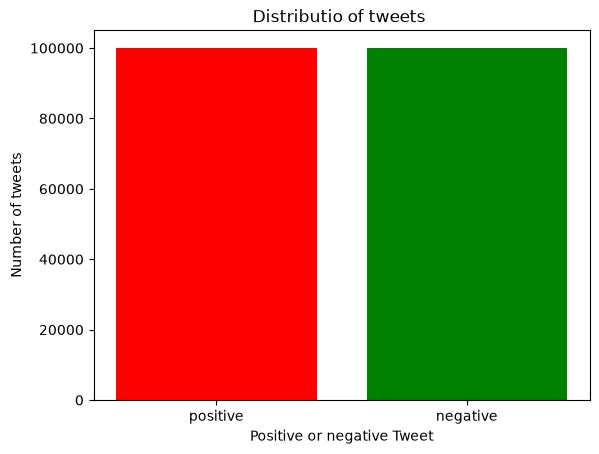

In [9]:
counts = data["target"].value_counts() # .value_count() returns a series containing frequency of each occurance

plt.bar(['positive','negative'],counts.values,color=["red","green"])
plt.title("Distributio of tweets ")
plt.xlabel('Positive or negative Tweet')
plt.ylabel("Number of tweets")

plt.show()

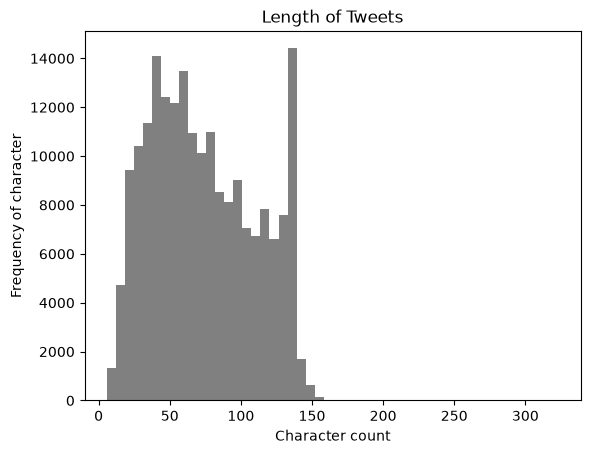

,target,text,length
0,1,Looks like the sun finally located Trondheim ;...,75
1,0,A long weekend begins. The sun is shining and ...,69
2,1,to the beach we go! hope it stays nice...,42
3,0,@JBFutureboy I missed it busted need to do a ...,93
4,0,Why I can't change my background image??,41


In [ ]:
data["length"] = data["text"].apply(len) # .apply() method apply the len function on each row of the data

plt.hist(data['length'],bins=50,color='grey')
plt.title("Length of Tweets")
plt.xlabel("Character count")
plt.ylabel("Frequency of character")
plt.show()
data.head()

In [ ]:
import re

def clean_tweet(text:str)->str:
    """ Removes any url, @-mention, #-hastags, puncutautions, Upper case, space more than one """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+","",text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_text"] = data["text"].apply(clean_tweet)
data[["text","clean_text"]].head()

,text,clean_text
0,Looks like the sun finally located Trondheim ;...,looks like the sun finally located trondheim h...
1,A long weekend begins. The sun is shining and ...,a long weekend begins the sun is shining and i...
2,to the beach we go! hope it stays nice...,to the beach we go hope it stays nice
3,@JBFutureboy I missed it busted need to do a ...,i missed it busted need to do a reunion tour t...
4,Why I can't change my background image??,why i cant change my background image


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X_train, X_test, Y_train, Y_test = train_test_split(
    data['clean_text'],data['target'],test_size = 0.2 , random_state=42
)

vectorizer = TfidfVectorizer(max_features = 5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)